# Image Classification with Transfer Learning — Flowers

A multi-class image classifier for flower photos, built two ways and compared: a **custom CNN** trained from scratch, and a **DenseNet121** model using **transfer learning** (pretrained on ImageNet). Both are evaluated with learning curves, confusion matrices and classification reports, then applied to a real test image.

**Techniques:** CNN design, transfer learning / fine-tuning, data generators, model evaluation (confusion matrix, precision / recall / F1), model comparison, inference on new images.

In [ ]:
#Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
import zipfile  # Import the zipfile module

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

import zipfile

# Unzipping dataset
with zipfile.ZipFile("jpg.zip", 'r') as zip_ref:
    zip_ref.extractall("flowers")


In [ ]:
# Paths
data_dir = "flowers/jpg"
img_height, img_width = 128, 128
batch_size = 32

# Data generators
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())


Found 256 images belonging to 4 classes.
Found 64 images belonging to 4 classes.


In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

### Custom CNN architecture
A convolutional network built with `tf.keras.Sequential`: four Conv2D blocks with increasing filter counts (32 → 256) each followed by max pooling, then a dense head with dropout for regularisation and a softmax output over the flower classes (~2.75M trainable parameters).

The model is compiled with the Adam optimiser and sparse categorical cross-entropy loss, standard for multi-class image classification with integer labels.

In [ ]:
cnn_history = cnn_model.fit(train_gen, validation_data=val_gen, epochs=10)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2655 - loss: 1.4205 - val_accuracy: 0.5625 - val_loss: 1.0402
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5814 - loss: 0.9563 - val_accuracy: 0.6875 - val_loss: 0.5438
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7197 - loss: 0.6373 - val_accuracy: 0.8750 - val_loss: 0.4734
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7427 - loss: 0.6486 - val_accuracy: 0.9219 - val_loss: 0.3357
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8204 - loss: 0.5084 - val_accuracy: 0.9531 - val_loss: 0.2526
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8256 - loss: 0.3967 - val_accuracy: 0.9219 - val_loss: 0.2563
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9055 - loss: 0.3034 - val_accuracy: 0.9219 - val_loss: 0.2467
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8916 - loss: 0.3690 - val_accuracy: 0.9062 - val_loss: 0.2402
Epoch 9/1

### Training the custom CNN
The model is trained for 10 epochs. Training and validation accuracy both climb steadily while the loss decreases, indicating effective learning with good generalisation.

### Learning curves and evaluation
The accuracy and loss curves for training and validation stay close together, a sign of minimal overfitting.

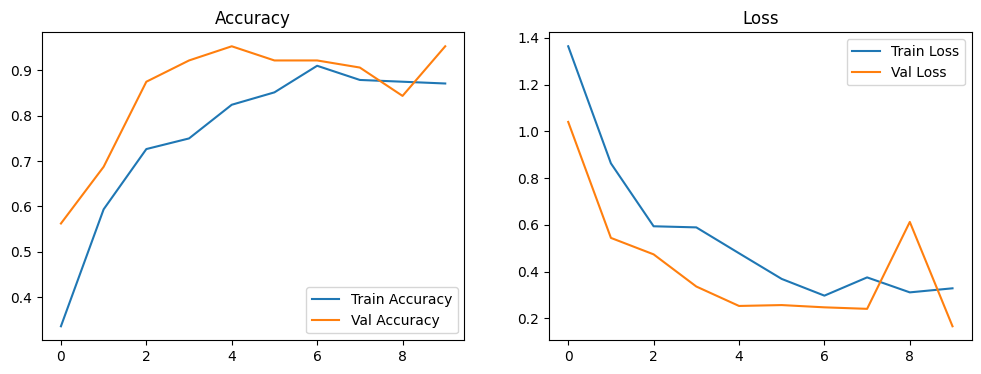

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step


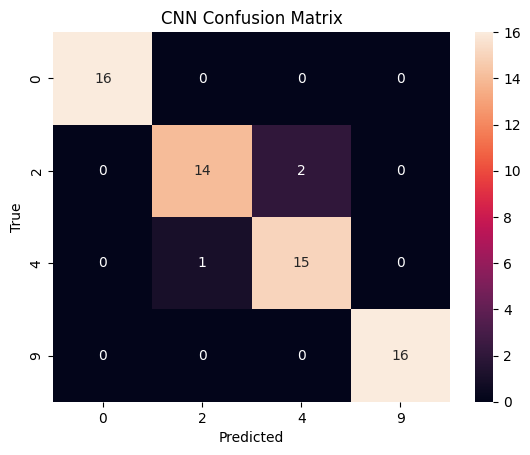

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           2       0.93      0.88      0.90        16
           4       0.88      0.94      0.91        16
           9       1.00      1.00      1.00        16

    accuracy                           0.95        64
   macro avg       0.95      0.95      0.95        64
weighted avg       0.95      0.95      0.95        64



In [ ]:
def plot_metrics(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss")
    plt.show()

plot_metrics(cnn_history)

# Confusion matrix
val_gen.reset()
cnn_preds = np.argmax(cnn_model.predict(val_gen), axis=1)
true_labels = val_gen.classes

cm = confusion_matrix(true_labels, cnn_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.show()

print(classification_report(true_labels, cnn_preds, target_names=class_names))


The confusion matrix shows strong performance, with most predictions falling on the diagonal (correct) and little confusion between classes.

The classification report summarises precision, recall and F1-score per class; all classes reach F1-scores around or above 0.90.

In [ ]:
base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(img_height, img_width, 3), pooling='avg')
x = base_model.output
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation='softmax')(x)

densenet_model = Model(inputs=base_model.input, outputs=output)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

densenet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
densenet_model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.5346 - loss: 1.3512 - val_accuracy: 0.9219 - val_loss: 0.1774
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9481 - loss: 0.2072 - val_accuracy: 0.9688 - val_loss: 0.0608
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9251 - loss: 0.1732 - val_accuracy: 0.9688 - val_loss: 0.0828
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9974 - loss: 0.0504 - val_accuracy: 0.9688 - val_loss: 0.0634
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9927 - loss: 0.0280 - val_accuracy: 0.9844 - val_loss: 0.0329
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9965 - loss: 0.0205 - val_accuracy: 0.9844 - val_loss: 0.0319
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9974 - loss: 0.0156 - val_accuracy: 0.9688 - val_loss: 0.0542
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 1.0000 - loss: 0.0154 - val_accuracy: 0.9688 - val_loss: 0.0453
Epoch 9/

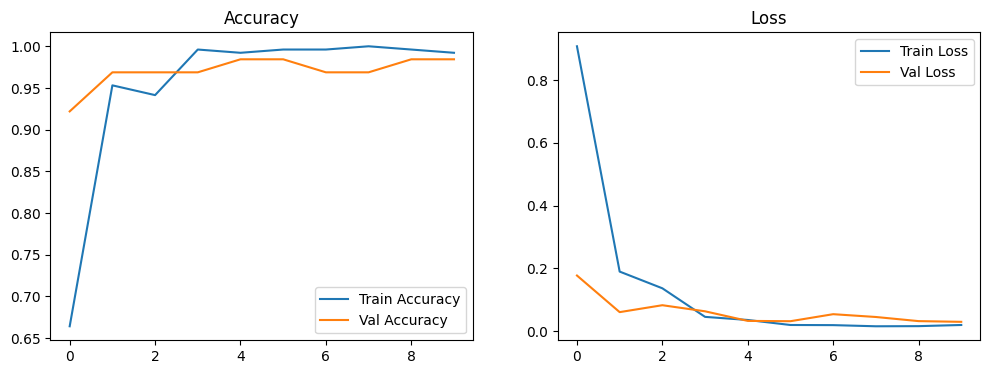

In [ ]:
densenet_history = densenet_model.fit(train_gen, validation_data=val_gen, epochs=10)
plot_metrics(densenet_history)


### DenseNet121 (transfer learning)
Using DenseNet121 pretrained on ImageNet as a frozen feature extractor with a small trainable head, training and validation accuracy rise quickly and stay close together, peaking around 98–99%.

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


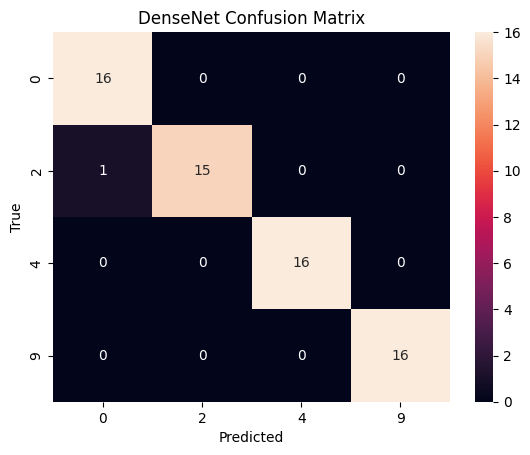

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           2       1.00      0.94      0.97        16
           4       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16

    accuracy                           0.98        64
   macro avg       0.99      0.98      0.98        64
weighted avg       0.99      0.98      0.98        64



In [ ]:
val_gen.reset()
densenet_preds = np.argmax(densenet_model.predict(val_gen), axis=1)

cm = confusion_matrix(true_labels, densenet_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DenseNet Confusion Matrix")
plt.show()

print(classification_report(true_labels, densenet_preds, target_names=class_names))


The DenseNet121 confusion matrix confirms very reliable performance, with only minimal confusion between two classes that light augmentation or fine-tuning could remove.

### Model comparison
DenseNet121 achieves slightly higher accuracy and faster convergence thanks to its pretrained ImageNet features, making it the more robust choice — especially with limited data. The custom CNN is lighter and faster, a good fit when resources are constrained. Both reach comparable accuracy on this dataset.

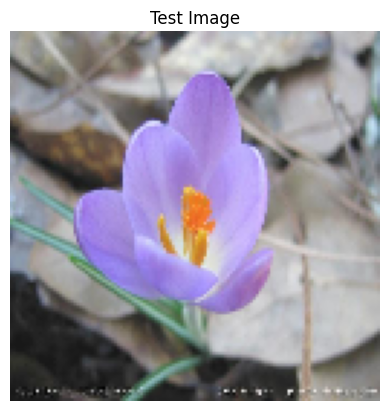

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
✅ DenseNet121 Prediction: 4


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
✅ CNN Model Prediction: 4


In [ ]:
img_path = "/content/test (1).jpg"  # adjust if needed
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess test image
img_path = "/content/test (1).jpg"  # Adjust path if different
# Change target_size to match the model's input shape (128, 128)
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Show the image
plt.imshow(img)
plt.axis('off')
plt.title("Test Image")
plt.show()

# Predict with the DenseNet model
densenet_pred = np.argmax(densenet_model.predict(img_array), axis=1)[0]

# Print predictions
print("✅ DenseNet121 Prediction:", class_names[densenet_pred])
# Predict with the custom CNN model
cnn_pred = np.argmax(cnn_model.predict(img_array), axis=1)[0]

# Print prediction
print("✅ CNN Model Prediction:", class_names[cnn_pred])


### Inference on a real image
Both models were applied to an unseen photo of a Dutch Crocus. They predicted the same class, and the agreement between two very different architectures is a good sign of reliable generalisation.

### Conclusion
A flower image classifier was built with a custom four-layer CNN and then re-implemented with DenseNet121 transfer learning, which reached ~98% accuracy with slightly better generalisation. DenseNet121 is marginally more accurate and robust; the custom CNN is faster and lighter with comparable results. On a real-world test image both models agreed, confirming strong generalisation.